In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("viditgandhi/tree-species-identification-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/tree-species-identification-dataset


In [ ]:
import shutil
import os

# Define the source and destination paths
source_path = path  # Using the 'path' variable from the previous cell
destination_path = "/content/tree-species-identification-dataset"

# Create the destination directory if it doesn't exist
if not os.path.exists(destination_path):
    os.makedirs(destination_path)

# Move the contents of the dataset to the destination
# Using copytree and then removing the original can be safer than shutil.move for directories across filesystems
try:
    shutil.copytree(source_path, destination_path, dirs_exist_ok=True)
    print(f"Dataset moved to: {destination_path}")
except Exception as e:
    print(f"Error moving dataset: {e}")
    # If copytree fails, try shutil.move as a fallback, though it might fail on different filesystems
    try:
        shutil.move(source_path, destination_path)
        print(f"Dataset moved to: {destination_path}")
    except Exception as e_move:
        print(f"Error moving dataset with shutil.move: {e_move}")

Dataset moved to: /content/tree-species-identification-dataset


In [ ]:
import os

repo_path = "/content/tree-species-identification-dataset/Tree_Species_Dataset"  # Adjust if cloned to a different name
print("Contents:", os.listdir(repo_path))

Contents: ['.git', 'motichanoti', 'sugarcane', 'kanchan', 'mango', 'other', 'neem', 'simlo', 'jamun', 'champa', 'shirish', 'pilikaren', 'coconut', 'banyan', 'sitafal', 'pipal', 'khajur', 'amla', 'vad', 'asopalav', 'bili', 'nilgiri', 'gunda', 'saptaparni', 'cactus', 'garmalo', 'gulmohor', 'babul', 'sonmahor', 'kesudo', 'bamboo']


In [ ]:
class_dirs = os.listdir(repo_path)
print(f"Number of classes: {len(class_dirs)}")


Number of classes: 31


In [ ]:
import glob

image_paths = []
labels = []

for class_name in os.listdir(repo_path):
    class_folder = os.path.join(repo_path, class_name)
    if os.path.isdir(class_folder):
        for img_file in os.listdir(class_folder):
            image_paths.append(os.path.join(class_folder, img_file))
            labels.append(class_name)

print(f"Total images: {len(image_paths)}")

Total images: 1605


In [ ]:
import pandas as pd

class_counts = {cls: len(os.listdir(os.path.join(repo_path, cls))) for cls in class_dirs}
class_counts_df = pd.DataFrame.from_dict(class_counts, orient='index', columns=['Image Count'])
print(class_counts_df.sort_values('Image Count', ascending=False).head())
print("shape: ",class_counts_df.shape)


             Image Count
other                150
sugarcane             50
motichanoti           50
mango                 50
kanchan               50
shape:  (31, 1)


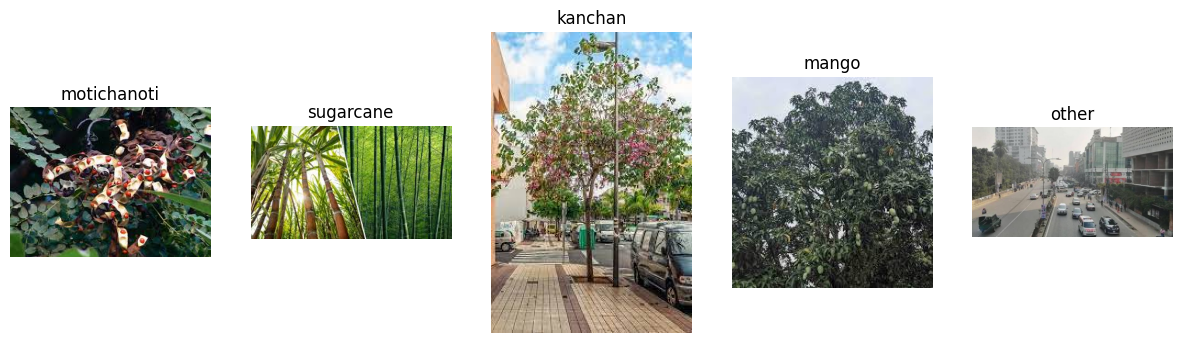

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import os

def show_sample_images(repo_path, class_dirs, n=5):
    # Filter out non-image directories like .git
    valid_class_dirs = [d for d in class_dirs if not d.startswith('.')]

    plt.figure(figsize=(15, 10))
    for i, class_dir in enumerate(valid_class_dirs[:n]):
        class_path = os.path.join(repo_path, class_dir)

        # Find the first image file in the directory
        img_file = next((f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))), None)

        if img_file:
            img_path = os.path.join(class_path, img_file)
            try:
                img = Image.open(img_path)
                plt.subplot(1, n, i+1)
                plt.imshow(img)
                plt.title(class_dir)
                plt.axis('off')
            except (IOError, UnidentifiedImageError):
                print(f"Could not open image: {img_path}")
        else:
            print(f"No image files found in: {class_path}")

    plt.show()

# It's better to get a fresh list of directories in case of changes
class_dirs = [d for d in os.listdir(repo_path) if os.path.isdir(os.path.join(repo_path, d))]
show_sample_images(repo_path, class_dirs)

In [ ]:
image_shapes = []

for class_dir in class_dirs:
    # Exclude hidden directories like .git
    if class_dir.startswith('.'):
        continue

    class_folder_path = os.path.join(repo_path, class_dir)
    if os.path.isdir(class_folder_path):
        for img_file in os.listdir(class_folder_path):
            img_path = os.path.join(class_folder_path, img_file)
            # Add a check to ensure the item is a file before trying to open it
            if os.path.isfile(img_path):
                try:
                    img = Image.open(img_path)
                    image_shapes.append(img.size)
                except UnidentifiedImageError:
                    # Skip files that are not images
                    print(f"Skipping non-image file: {img_path}")
                    pass


# DataFrame and Summary
import pandas as pd

shapes_df = pd.DataFrame(image_shapes, columns=["Width", "Height"])
shapes_df.head()

,Width,Height
0,259,194
1,194,259
2,265,190
3,266,190
4,225,225


In [ ]:
print(shapes_df.describe())


             Width       Height
count  1600.000000  1600.000000
mean    312.623125   269.821875
std     296.220501   278.014229
min     141.000000   128.000000
25%     225.000000   183.000000
50%     259.000000   200.000000
75%     275.000000   259.000000
max    4000.000000  4032.000000


In [ ]:
import hashlib
from collections import defaultdict
import os # Import os if it's not already imported in this cell

hashes = defaultdict(list)

for class_dir in class_dirs:
    # Exclude hidden directories like .git
    if class_dir.startswith('.'):
        continue

    class_folder_path = os.path.join(repo_path, class_dir)
    if os.path.isdir(class_folder_path): # Ensure it's a directory
        for img_file in os.listdir(class_folder_path):
            img_path = os.path.join(class_folder_path, img_file)
            # Check if it's a file before trying to open
            if os.path.isfile(img_path):
                with open(img_path, 'rb') as f:
                    file_hash = hashlib.md5(f.read()).hexdigest()
                    hashes[file_hash].append(img_path)

# Filter duplicates
duplicates = {h: files for h, files in hashes.items() if len(files) > 1}
print("Duplicate image sets found:", len(duplicates))


Duplicate image sets found: 82


In [ ]:
import os
from PIL import Image, UnidentifiedImageError

corrupt_images = []

for class_dir in class_dirs:
    # Exclude hidden directories like .git
    if class_dir.startswith('.'):
        continue

    class_folder_path = os.path.join(repo_path, class_dir)
    if os.path.isdir(class_folder_path):
        for img_file in os.listdir(class_folder_path):
            img_path = os.path.join(class_folder_path, img_file)
            # Check if it's a file before trying to open
            if os.path.isfile(img_path):
                try:
                    img = Image.open(img_path)
                    img.verify() # Verify the image integrity
                except (IOError, SyntaxError, UnidentifiedImageError) as e:
                    # Catch specific image-related errors
                    corrupt_images.append(img_path)
                    print(f"Found corrupted image: {img_path} - {e}")
                except Exception as e:
                    # Catch any other unexpected errors
                    corrupt_images.append(img_path)
                    print(f"Found potential issue with file: {img_path} - {e}")


print("\nTotal corrupted or problematic images found:", len(corrupt_images))


Total corrupted or problematic images found: 0


Duplicate set 1:


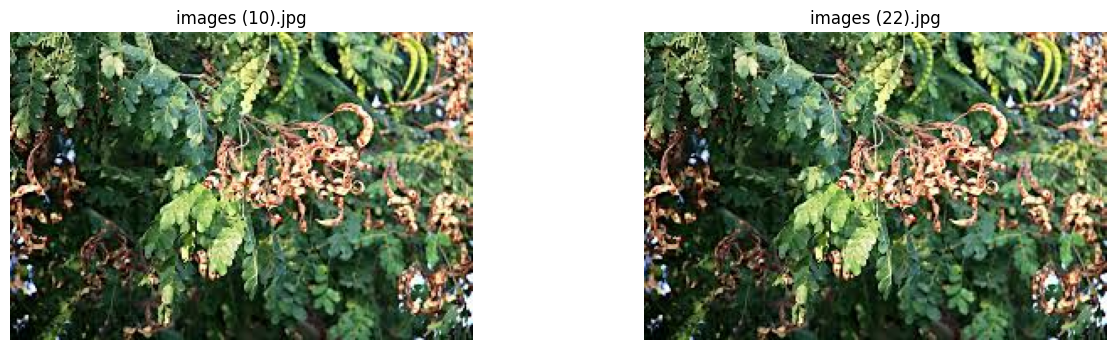

Duplicate set 2:


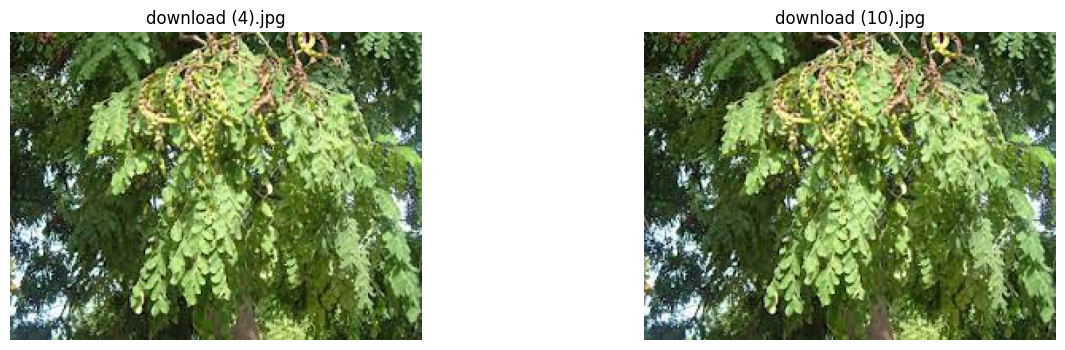

Duplicate set 3:


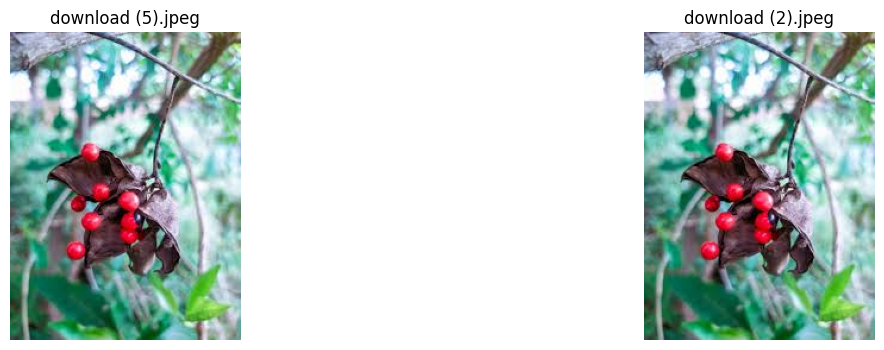

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

def show_duplicate_sets(duplicates, sets_to_display=3):
    shown = 0
    for hash_val, dup_paths in duplicates.items():
        if shown >= sets_to_display:
            break
        print(f"Duplicate set {shown + 1}:")
        plt.figure(figsize=(15, 4))
        for i, img_path in enumerate(dup_paths):
            try:
                img = Image.open(img_path)
                plt.subplot(1, len(dup_paths), i+1)
                plt.imshow(img)
                plt.title(os.path.basename(img_path))
                plt.axis('off')
            except:
                continue
        plt.show()
        shown += 1

show_duplicate_sets(duplicates, sets_to_display=3)

In [ ]:
import os

removed_count = 0

for dup_list in duplicates.values():
    # Keep the first, delete rest
    for img_path in dup_list[1:]:
        try:
            os.remove(img_path)
            removed_count += 1
        except Exception as e:
            print(f"Error deleting {img_path}: {e}")

print(f"✅ Removed {removed_count} duplicate images.")

Error deleting /content/tree-species-identification-dataset/Tree_Species_Dataset/motichanoti/images (22).jpg: [Errno 2] No such file or directory: '/content/tree-species-identification-dataset/Tree_Species_Dataset/motichanoti/images (22).jpg'
Error deleting /content/tree-species-identification-dataset/Tree_Species_Dataset/motichanoti/download (10).jpg: [Errno 2] No such file or directory: '/content/tree-species-identification-dataset/Tree_Species_Dataset/motichanoti/download (10).jpg'
Error deleting /content/tree-species-identification-dataset/Tree_Species_Dataset/motichanoti/download (2).jpeg: [Errno 2] No such file or directory: '/content/tree-species-identification-dataset/Tree_Species_Dataset/motichanoti/download (2).jpeg'
Error deleting /content/tree-species-identification-dataset/Tree_Species_Dataset/motichanoti/images (24).jpg: [Errno 2] No such file or directory: '/content/tree-species-identification-dataset/Tree_Species_Dataset/motichanoti/images (24).jpg'
Error deleting /cont

In [ ]:
from PIL import Image
import pandas as pd

# Gather image info
image_info = []

for class_dir in class_dirs:
    class_path = os.path.join(repo_path, class_dir)
    for img_file in os.listdir(class_path):
        img_path = os.path.join(class_path, img_file)
        try:
            with Image.open(img_path) as img:
                width, height = img.size
                image_info.append({
                    'path': img_path,
                    'width': width,
                    'height': height,
                    'class': class_dir
                })
        except:
            continue

df_sizes = pd.DataFrame(image_info)

# Define thresholds
small_imgs = df_sizes[(df_sizes['width'] < 150) | (df_sizes['height'] < 150)]
large_imgs = df_sizes[(df_sizes['width'] > 1000) | (df_sizes['height'] > 2000)]

print(f"🔻 Very small images: {len(small_imgs)}")
print(f"🔺 Very large images: {len(large_imgs)}")


🔻 Very small images: 20
🔺 Very large images: 40


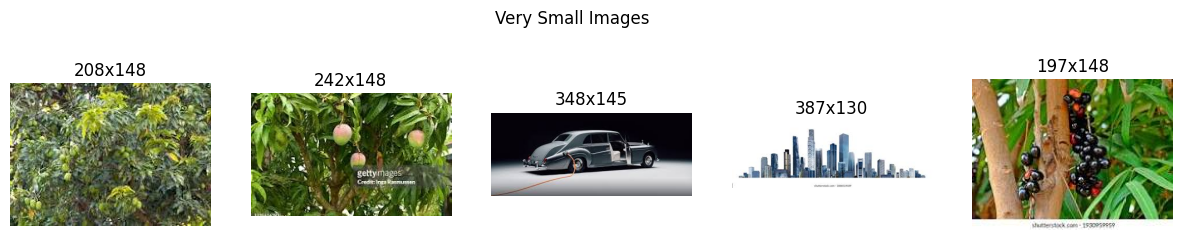

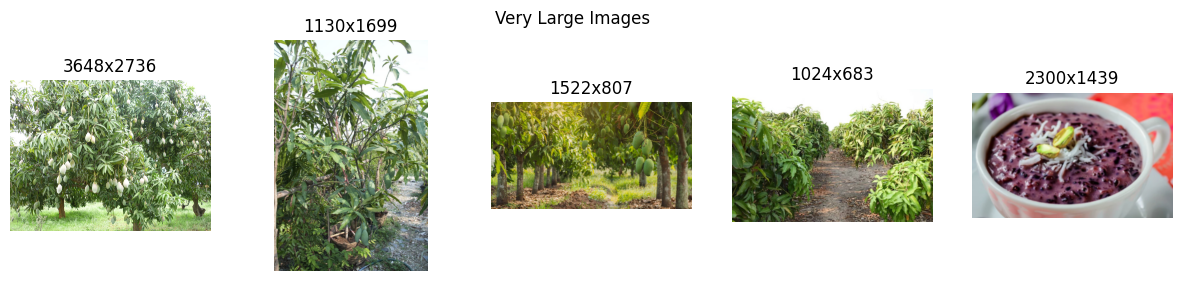

In [ ]:
def show_images(df_subset, title, n=5):
    plt.figure(figsize=(15, 3))
    for i, (_, row) in enumerate(df_subset.head(n).iterrows()):
        img = Image.open(row['path'])
        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.title(f"{row['width']}x{row['height']}")
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

show_images(small_imgs, "Very Small Images")
show_images(large_imgs, "Very Large Images")


In [ ]:
import os

# Combine both sets
outliers = pd.concat([small_imgs, large_imgs])

# Remove them
removed_count = 0
for path in outliers['path']:
    try:
        os.remove(path)
        removed_count += 1
    except Exception as e:
        print(f"Failed to remove {path}: {e}")

print(f"🗑️ Removed {removed_count} outlier images (small + large).")


Failed to remove /content/tree-species-identification-dataset/Tree_Species_Dataset/mango/image33.jpg: [Errno 2] No such file or directory: '/content/tree-species-identification-dataset/Tree_Species_Dataset/mango/image33.jpg'
Failed to remove /content/tree-species-identification-dataset/Tree_Species_Dataset/mango/download.jpeg: [Errno 2] No such file or directory: '/content/tree-species-identification-dataset/Tree_Species_Dataset/mango/download.jpeg'
Failed to remove /content/tree-species-identification-dataset/Tree_Species_Dataset/other/8.jpg: [Errno 2] No such file or directory: '/content/tree-species-identification-dataset/Tree_Species_Dataset/other/8.jpg'
Failed to remove /content/tree-species-identification-dataset/Tree_Species_Dataset/other/download (2).jpeg: [Errno 2] No such file or directory: '/content/tree-species-identification-dataset/Tree_Species_Dataset/other/download (2).jpeg'
Failed to remove /content/tree-species-identification-dataset/Tree_Species_Dataset/jamun/sample.

In [ ]:
image_info = []

for class_dir in class_dirs:
    class_path = os.path.join(repo_path, class_dir)
    for img_file in os.listdir(class_path):
        img_path = os.path.join(class_path, img_file)
        try:
            with Image.open(img_path) as img:
                width, height = img.size
                image_info.append({
                    'path': img_path,
                    'width': width,
                    'height': height,
                    'class': class_dir
                })
        except:
            continue

df_sizes = pd.DataFrame(image_info)
print(df_sizes[['width', 'height']].describe())


             width       height
count  1454.000000  1454.000000
mean    275.872765   239.044704
std     117.507849   117.197342
min     150.000000   150.000000
25%     225.000000   183.000000
50%     259.000000   198.000000
75%     275.000000   256.000000
max    1000.000000  1247.000000


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define parameters
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

# Augmentation and rescaling
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True
)

train_gen = datagen.flow_from_directory(
    repo_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_gen = datagen.flow_from_directory(
    repo_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 1177 images belonging to 31 classes.
Found 277 images belonging to 31 classes.


In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

base_model = EfficientNetB0(include_top=False, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3), weights='imagenet')
base_model.trainable = False  # Freeze base model

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(train_gen.num_classes, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 31)             │         3,999 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,217,538 (16.09 MB)

 Trainable params: 167,967 (656.12 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [32]:
EPOCHS = 10

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 147s 4s/step - accuracy: 0.0389 - loss: 3.4706 - val_accuracy: 0.0903 - val_loss: 3.3946
Epoch 2/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 128s 3s/step - accuracy: 0.0843 - loss: 3.4139 - val_accuracy: 0.0903 - val_loss: 3.3978
Epoch 3/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 141s 3s/step - accuracy: 0.0772 - loss: 3.4087 - val_accuracy: 0.0903 - val_loss: 3.3862
Epoch 4/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 128s 3s/step - accuracy: 0.0795 - loss: 3.4089 - val_accuracy: 0.0903 - val_loss: 3.3850
Epoch 5/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 141s 3s/step - accuracy: 0.1008 - loss: 3.4052 - val_accuracy: 0.0903 - val_loss: 3.3970
Epoch 6/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 129s 3s/step - accuracy: 0.0838 - loss: 3.4019 - val_accuracy: 0.0903 - val_loss: 3.3812
Epoch 7/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 144s 4s/step - accuracy: 0.0773 - loss: 3.4014 - val_accuracy: 0.0903 - val_loss: 3.3774
Epoch 8/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 126s 3s/step - accuracy: 0.0838 - loss: 3.4007 - val_accuracy: 0.0903 - v

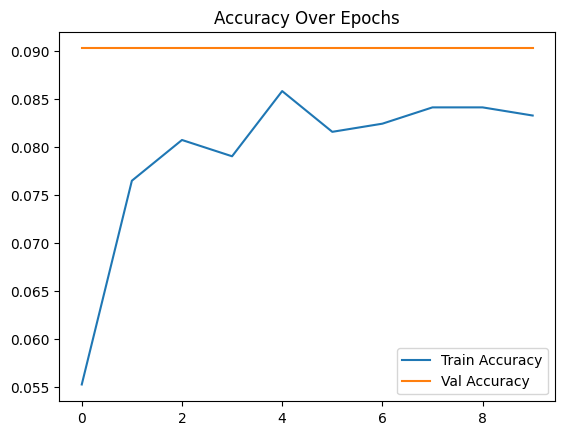

In [33]:

import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy Over Epochs")
plt.show()

# Save model
model.save("tree_species_model.h5")

In [34]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define image properties
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

# Data generators
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_generator = datagen.flow_from_directory(
    repo_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator = datagen.flow_from_directory(
    repo_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)
num_classes = train_generator.num_classes

# Build a basic CNN model
model_cnn = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')  # Use num_classes here
])

model_cnn.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Train the model
EPOCHS = 10
history_cnn = model_cnn.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator
)

# Save the model
model_cnn.save('basic_cnn_tree_species.h5')
print("✅ Basic CNN model saved as 'basic_cnn_tree_species.h5'")

Found 1177 images belonging to 31 classes.
Found 277 images belonging to 31 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 191s 5s/step - accuracy: 0.0482 - loss: 3.8654 - val_accuracy: 0.1011 - val_loss: 3.2992
Epoch 2/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 180s 5s/step - accuracy: 0.0966 - loss: 3.3041 - val_accuracy: 0.1336 - val_loss: 3.0891
Epoch 3/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 181s 5s/step - accuracy: 0.1441 - loss: 3.1303 - val_accuracy: 0.1444 - val_loss: 2.9628
Epoch 4/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 207s 5s/step - accuracy: 0.1378 - loss: 3.0277 - val_accuracy: 0.1769 - val_loss: 2.8345
Epoch 5/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 180s 5s/step - accuracy: 0.1831 - loss: 2.8917 - val_accuracy: 0.2202 - val_loss: 2.8038
Epoch 6/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 181s 5s/step - accuracy: 0.1880 - loss: 2.8677 - val_accuracy: 0.2310 - val_loss: 2.7287
Epoch 7/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 211s 5s/step - accuracy: 0.2068 - loss: 2.7652 - val_accuracy: 0.2708 - val_loss: 2.6132
Epoch 8/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 185s 5s/step - accuracy: 0.2130 - loss: 2.7520 - val_accuracy: 0.2563 - v

✅ Basic CNN model saved as 'basic_cnn_tree_species.h5'


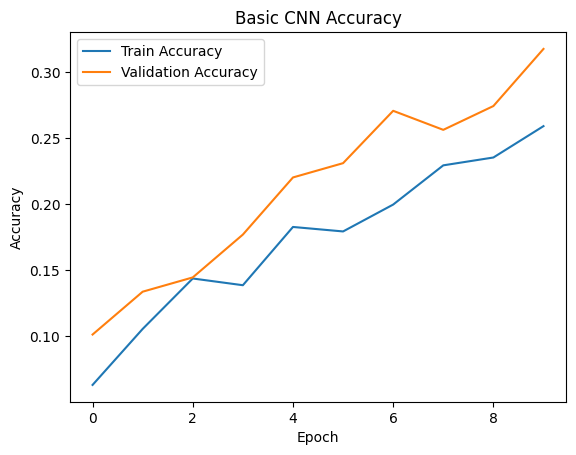

In [35]:
import matplotlib.pyplot as plt

plt.plot(history_cnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
plt.title("Basic CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')  # Use num_classes here to match the generator
])

model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

model.fit(train_generator, validation_data=val_generator, epochs=25)

model.save("improved_cnn_model.h5")

Epoch 1/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 266s 7s/step - accuracy: 0.0646 - loss: 5.1743 - val_accuracy: 0.0361 - val_loss: 8.4075
Epoch 2/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 260s 7s/step - accuracy: 0.1112 - loss: 3.2494 - val_accuracy: 0.0361 - val_loss: 14.1233
Epoch 3/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 265s 7s/step - accuracy: 0.1244 - loss: 3.2219 - val_accuracy: 0.0361 - val_loss: 15.4925
Epoch 4/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 250s 7s/step - accuracy: 0.1198 - loss: 3.2093 - val_accuracy: 0.0542 - val_loss: 14.9782
Epoch 5/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 262s 7s/step - accuracy: 0.1220 - loss: 3.1294 - val_accuracy: 0.0361 - val_loss: 16.1517
Epoch 6/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 250s 7s/step - accuracy: 0.1760 - loss: 3.0043 - val_accuracy: 0.0397 - val_loss: 15.2099
Epoch 7/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 264s 7s/step - accuracy: 0.1441 - loss: 3.1590 - val_accuracy: 0.0469 - val_loss: 13.1292
Epoch 8/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 253s 7s/step - accuracy: 0.1696 - loss: 3.0789 - val_accuracy: 0.04

✅ Improved CNN with Batch Normalization model loaded from 'improved_cnn_model.h5'
9/9 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.2180 - loss: 2.9936
Validation Accuracy: 0.2166064977645874


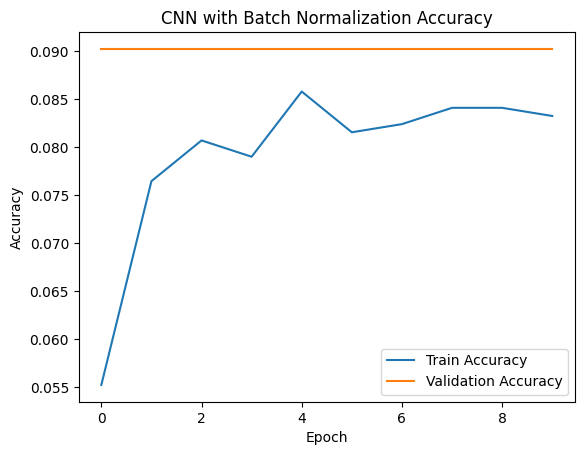

In [38]:
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# Load the improved model
model = load_model("improved_cnn_model.h5")
print("✅ Improved CNN with Batch Normalization model loaded from 'improved_cnn_model.h5'")

# You can now use this model for evaluation or prediction.
# For example, let's re-evaluate on the validation set:
loss, accuracy = model.evaluate(val_generator)
print(f"Validation Accuracy: {accuracy}")

# If you have the training history from the previous run, you can plot it
# Assuming history was saved from the execution of cell OCpNYpMRDwYX
# This part of the code will not run if 'history' is not available
# from the previous execution.
if 'history' in locals() or 'history' in globals():
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title("CNN with Batch Normalization Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()